<a href="https://colab.research.google.com/github/janamm11/world-indicators-dashboard/blob/main/worldBankAPI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

! pip install requests

In [2]:
import requests

In [3]:
#importing country names from the api
url=  "https://api.worldbank.org/countries?format=json&per_page=300"

response= requests.get(url)
response.status_code

200

In [4]:
data= response.json()
print(data[0])
print(len(data))

# 1- metadata
# 2 -Actual data

{'page': 1, 'pages': 1, 'per_page': '300', 'total': 295}
2


In [5]:
countries= data[1]
countries= pd.DataFrame(countries)

In [6]:
print(data[1][0])  # prints first country's full dictionary

{'id': 'ABW', 'iso2Code': 'AW', 'name': 'Aruba', 'region': {'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Latin America & Caribbean '}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'}, 'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'}, 'capitalCity': 'Oranjestad', 'longitude': '-70.0167', 'latitude': '12.5167'}


In [7]:
countries

,id,iso2Code,name,region,adminregion,incomeLevel,lendingType,capitalCity,longitude,latitude
0,ABW,AW,Aruba,"{'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Lati...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'HIC', 'iso2code': 'XD', 'value': 'High...","{'id': 'LNX', 'iso2code': 'XX', 'value': 'Not ...",Oranjestad,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
2,AFG,AF,Afghanistan,"{'id': 'MEA', 'iso2code': 'ZQ', 'value': 'Midd...","{'id': 'MNA', 'iso2code': 'XQ', 'value': 'Midd...","{'id': 'LIC', 'iso2code': 'XM', 'value': 'Low ...","{'id': 'IDX', 'iso2code': 'XI', 'value': 'IDA'}",Kabul,69.1761,34.5228
3,AFR,A9,Africa,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
4,AFW,ZI,Africa Western and Central,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
...,...,...,...,...,...,...,...,...,...,...
290,XZN,A5,Sub-Saharan Africa excluding South Africa and ...,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
291,YEM,YE,"Yemen, Rep.","{'id': 'MEA', 'iso2code': 'ZQ', 'value': 'Midd...","{'id': 'MNA', 'iso2code': 'XQ', 'value': 'Midd...","{'id': 'LIC', 'iso2code': 'XM', 'value': 'Low ...","{'id': 'IDX', 'iso2code': 'XI', 'value': 'IDA'}",Sana'a,44.2075,15.352
292,ZAF,ZA,South Africa,"{'id': 'SSF', 'iso2code': 'ZG', 'value': 'Sub-...","{'id': 'SSA', 'iso2code': 'ZF', 'value': 'Sub-...","{'id': 'UMC', 'iso2code': 'XT', 'value': 'Uppe...","{'id': 'IBD', 'iso2code': 'XF', 'value': 'IBRD'}",Pretoria,28.1871,-25.746
293,ZMB,ZM,Zambia,"{'id': 'SSF', 'iso2code': 'ZG', 'value': 'Sub-...","{'id': 'SSA', 'iso2code': 'ZF', 'value': 'Sub-...","{'id': 'LMC', 'iso2code': 'XN', 'value': 'Lowe...","{'id': 'IDX', 'iso2code': 'XI', 'value': 'IDA'}",Lusaka,28.2937,-15.3982


In [8]:
countries["incomeLevel"][4]

{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggregates'}

In [9]:
countries["region"][6]

{'id': 'ECS', 'iso2code': 'Z7', 'value': 'Europe & Central Asia'}

In [10]:
#cleaning the columns one by one
countries["region"]= countries["region"].apply(lambda x:x["value"])

In [11]:
countries["incomeLevel"]= countries["incomeLevel"].apply(lambda x:x["value"])

In [12]:
countries["lendingType"]= countries["lendingType"].apply(lambda x:x["value"])

In [13]:
countries.drop(columns=["adminregion","adminregion"], inplace=True)

In [14]:
countries.drop(columns=["capitalCity"], inplace=True)

In [15]:
countries

,id,iso2Code,name,region,incomeLevel,lendingType,longitude,latitude
0,ABW,AW,Aruba,Latin America & Caribbean,High income,Not classified,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
2,AFG,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,69.1761,34.5228
3,AFR,A9,Africa,Aggregates,Aggregates,Aggregates,,
4,AFW,ZI,Africa Western and Central,Aggregates,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...,...
290,XZN,A5,Sub-Saharan Africa excluding South Africa and ...,Aggregates,Aggregates,Aggregates,,
291,YEM,YE,"Yemen, Rep.","Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,44.2075,15.352
292,ZAF,ZA,South Africa,Sub-Saharan Africa,Upper middle income,IBRD,28.1871,-25.746
293,ZMB,ZM,Zambia,Sub-Saharan Africa,Lower middle income,IDA,28.2937,-15.3982


In [16]:
countries['region'].unique()

array(['Latin America & Caribbean ', 'Aggregates',
       'Middle East, North Africa, Afghanistan & Pakistan',
       'Sub-Saharan Africa ', 'Europe & Central Asia',
       'East Asia & Pacific', 'South Asia', 'North America'], dtype=object)

In [17]:
countries.rename(columns={'iso2Code':'country_id'},inplace=True)

In [18]:
countries[countries["region"]=="Aggregates"]

,id,country_id,name,region,incomeLevel,lendingType,longitude,latitude
1,AFE,ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
3,AFR,A9,Africa,Aggregates,Aggregates,Aggregates,,
4,AFW,ZI,Africa Western and Central,Aggregates,Aggregates,Aggregates,,
8,ARB,1A,Arab World,Aggregates,Aggregates,Aggregates,,
18,BEA,B4,East Asia & Pacific (IBRD-only countries),Aggregates,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...,...
268,TSA,T5,South Asia (IDA & IBRD),Aggregates,Aggregates,Aggregates,,
269,TSS,T6,Sub-Saharan Africa (IDA & IBRD countries),Aggregates,Aggregates,Aggregates,,
277,UMC,XT,Upper middle income,Aggregates,Aggregates,Aggregates,,
287,WLD,1W,World,Aggregates,Aggregates,Aggregates,,


In [19]:
# code for indicators
base_url="https://api.worldbank.org/v2/indicators?format=json"
response= requests.get(base_url)
response.status_code

200

In [20]:
indicators_data= response.json()

In [21]:
indicators_data[0]

{'page': 1, 'pages': 592, 'per_page': '50', 'total': 29556}

In [22]:
indicators_data[1]

[{'id': '1.0.HCount.1.90usd',
  'name': 'Poverty Headcount ($1.90 a day)',
  'unit': '',
  'source': {'id': '37', 'value': 'LAC Equity Lab'},
  'sourceNote': 'The poverty headcount index measures the proportion of the population with daily per capita income (in 2011 PPP) below the poverty line.',
  'sourceOrganization': 'LAC Equity Lab tabulations of SEDLAC (CEDLAS and the World Bank).',
  'topics': [{'id': '11', 'value': 'Poverty '}]},
 {'id': '1.0.HCount.2.5usd',
  'name': 'Poverty Headcount ($2.50 a day)',
  'unit': '',
  'source': {'id': '37', 'value': 'LAC Equity Lab'},
  'sourceNote': 'The poverty headcount index measures the proportion of the population with daily per capita income (in 2005 PPP) below the poverty line.',
  'sourceOrganization': 'LAC Equity Lab tabulations of SEDLAC (CEDLAS and the World Bank).',
  'topics': [{'id': '11', 'value': 'Poverty '}]},
 {'id': '1.0.HCount.Mid10to50',
  'name': 'Middle Class ($10-50 a day) Headcount',
  'unit': '',
  'source': {'id': '37

In [23]:
all_dfs = []
for i in range(1, 61):
    url = f"https://api.worldbank.org/v2/indicators?format=json&per_page=500&page={i}"
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()
        indicators = data[1]
        df = pd.DataFrame([{"id": item["id"], "name": item["name"]} for item in indicators])
        all_dfs.append(df)
        print(f"Page {i}: {len(df)} indicators collected")
    else:
        print(f"Failed at page {i}")

final_df = pd.concat(all_dfs, ignore_index=True)
final_df.to_csv("final_df.csv")

Page 1: 500 indicators collected
Page 2: 500 indicators collected
Page 3: 500 indicators collected
Page 4: 500 indicators collected
Page 5: 500 indicators collected
Page 6: 500 indicators collected
Page 7: 500 indicators collected
Page 8: 500 indicators collected
Page 9: 500 indicators collected
Page 10: 500 indicators collected
Page 11: 500 indicators collected
Page 12: 500 indicators collected
Page 13: 500 indicators collected
Page 14: 500 indicators collected
Page 15: 500 indicators collected
Page 16: 500 indicators collected
Page 17: 500 indicators collected
Page 18: 500 indicators collected
Page 19: 500 indicators collected
Page 20: 500 indicators collected
Page 21: 500 indicators collected
Page 22: 500 indicators collected
Page 23: 500 indicators collected
Page 24: 500 indicators collected
Page 25: 500 indicators collected
Page 26: 500 indicators collected
Page 27: 500 indicators collected
Page 28: 500 indicators collected
Page 29: 500 indicators collected
Page 30: 500 indicators

In [24]:
## extacing value for various indicators under the domain for each country
# search for poverty related indicators
final_df[final_df["name"].str.contains("poverty", case=False)]

,id,name
0,1.0.HCount.1.90usd,Poverty Headcount ($1.90 a day)
1,1.0.HCount.2.5usd,Poverty Headcount ($2.50 a day)
3,1.0.HCount.Ofcl,Official Moderate Poverty Rate-National
4,1.0.HCount.Poor4uds,Poverty Headcount ($4 a day)
6,1.0.PGap.1.90usd,Poverty Gap ($1.90 a day)
...,...,...
26230,SI.POV.UMIC.GP,Poverty gap at $8.30 a day (2021 PPP) (%)
26231,SI.POV.URGP,Urban poverty gap at national poverty lines (%)
26232,SI.POV.URHC,Urban poverty headcount ratio at national pove...
27007,SPI.D1.5.POV,Availability of Comparable Poverty headcount r...


In [25]:
# search for health related indicators
final_df[final_df["name"].str.contains("life expectancy", case=False)]

,id,name
24878,SE.SCH.LIFE,"School life expectancy, primary to tertiary, b..."
24879,SE.SCH.LIFE.FE,"School life expectancy, primary to tertiary, f..."
24880,SE.SCH.LIFE.MA,"School life expectancy, primary to tertiary, m..."
26566,SP.DYN.LE00.FE.IN,"Life expectancy at birth, female (years)"
26567,SP.DYN.LE00.IN,"Life expectancy at birth, total (years)"
26568,SP.DYN.LE00.MA.IN,"Life expectancy at birth, male (years)"
26569,SP.DYN.LE60.FE.IN,"Life expectancy at age 60, female (years)"
26570,SP.DYN.LE60.MA.IN,"Life expectancy at age 60, male (years)"
29185,UIS.SLE.02,"School life expectancy, pre-primary, both sexe..."
29186,UIS.SLE.02.F,"School life expectancy, pre-primary, female (y..."


In [26]:


# search for internet related indicators
final_df[final_df["name"].str.contains("internet", case=False)]

,id,name
114,2.0.cov.Int,Coverage: Internet
139,2.0.hoi.Int,HOI: Internet
3531,con26d,Daily internet use (% age 15+)
3532,con26d.1,"Daily internet use, women (% age 15+)"
3533,con26d.10,"Daily internet use, urban (% age 15+)"
...,...,...
25043,SF.CMN.INET.USER.10K,"Internet users (per 10,000 people)"
29163,UIS.SCHBSP.1.WINTERN,Proportion of primary schools with access to I...
29171,UIS.SCHBSP.2.WINTERN,Proportion of lower secondary schools with acc...
29176,UIS.SCHBSP.2T3.WINTERN,Proportion of secondary schools with access to...


In [27]:
indicator_groups = {
"economic_activity_growth": [
"NY.GDP.MKTP.KD.ZG", # GDP growth (annual %)
"NY.GDP.PCAP.CD" # GDP per capita (current US$)
],
"labour_market_indicators": [
"SL.UEM.TOTL.ZS", # Unemployment total
"SL.UEM.1524.ZS", # Unemployment youth total (ages 15–24)
"SL.TLF.TOTL.IN" # Labour force, total
],
"trade_globalization": [
"NE.EXP.GNFS.CD", # Exports of goods and services (current US$)
"NE.IMP.GNFS.CD" # Imports of goods and services (current US$)
],
"poverty_inequality": [
"SI.POV.NAHC", # Poverty headcount ratio at national poverty lines (% of population)
"SI.POV.GINI" # Gini index (measure of income inequality)
],
"environmental_indicators": [
"EG.FEC.RNEW.ZS", # Renewable energy consumption (% of total final energy consumption)
"AG.LND.FRST.ZS" # Forest area (% of land area)
],
"health_indicators": [
"SP.DYN.LE00.IN", # Life expectancy at birth
"SP.DYN.IMRT.IN", # Infant mortality rate
"SH.H2O.BASW.ZS", # Access to at least basic water services (% of population)
"SH.XPD.CHEX.GD.ZS", # Current health expenditure (% of GDP)
"SH.IMM.IDPT", # Immunization, DPT (% of children ages 12–23 months)
"SH.IMM.MEAS", # Immunization, measles (% of children ages 12–23 months)
"SH.MMR.RISK.ZS", # Risk of maternal death
"SH.DTH.COMM.ZS", # Deaths from communicable diseases (% of total)
"SH.TBS.INCD", # Tuberculosis incidence (per 100,000 people)
"SH.STA.BRTC.ZS", # Births attended by skilled health staff (%)
"SH.STA.MMRT", # Maternal mortality ratio (modeled estimate, per 100,000 live births)
"SP.POP.65UP.TO.ZS", # Population ages 65 and above (% of total population)
"SH.HIV.INCD.ZS" # HIV incidence rate (per 1,000 uninfected population ages 15–49)
],
"technology_indicators": [
"IT.NET.USER.ZS", # Individuals using the Internet (% of population)
"IT.CEL.SETS.P2" # Mobile cellular subscriptions (per 100 people)
]}

In [28]:
indicator_groups.items()

dict_items([('economic_activity_growth', ['NY.GDP.MKTP.KD.ZG', 'NY.GDP.PCAP.CD']), ('labour_market_indicators', ['SL.UEM.TOTL.ZS', 'SL.UEM.1524.ZS', 'SL.TLF.TOTL.IN']), ('trade_globalization', ['NE.EXP.GNFS.CD', 'NE.IMP.GNFS.CD']), ('poverty_inequality', ['SI.POV.NAHC', 'SI.POV.GINI']), ('environmental_indicators', ['EG.FEC.RNEW.ZS', 'AG.LND.FRST.ZS']), ('health_indicators', ['SP.DYN.LE00.IN', 'SP.DYN.IMRT.IN', 'SH.H2O.BASW.ZS', 'SH.XPD.CHEX.GD.ZS', 'SH.IMM.IDPT', 'SH.IMM.MEAS', 'SH.MMR.RISK.ZS', 'SH.DTH.COMM.ZS', 'SH.TBS.INCD', 'SH.STA.BRTC.ZS', 'SH.STA.MMRT', 'SP.POP.65UP.TO.ZS', 'SH.HIV.INCD.ZS']), ('technology_indicators', ['IT.NET.USER.ZS', 'IT.CEL.SETS.P2'])])

In [29]:
for i,j in indicator_groups.items(): # checking if everything fine
  print(i)
  print(j)

economic_activity_growth
['NY.GDP.MKTP.KD.ZG', 'NY.GDP.PCAP.CD']
labour_market_indicators
['SL.UEM.TOTL.ZS', 'SL.UEM.1524.ZS', 'SL.TLF.TOTL.IN']
trade_globalization
['NE.EXP.GNFS.CD', 'NE.IMP.GNFS.CD']
poverty_inequality
['SI.POV.NAHC', 'SI.POV.GINI']
environmental_indicators
['EG.FEC.RNEW.ZS', 'AG.LND.FRST.ZS']
health_indicators
['SP.DYN.LE00.IN', 'SP.DYN.IMRT.IN', 'SH.H2O.BASW.ZS', 'SH.XPD.CHEX.GD.ZS', 'SH.IMM.IDPT', 'SH.IMM.MEAS', 'SH.MMR.RISK.ZS', 'SH.DTH.COMM.ZS', 'SH.TBS.INCD', 'SH.STA.BRTC.ZS', 'SH.STA.MMRT', 'SP.POP.65UP.TO.ZS', 'SH.HIV.INCD.ZS']
technology_indicators
['IT.NET.USER.ZS', 'IT.CEL.SETS.P2']


In [30]:
# response= requests.get (' https://api.worldbank.org/countries/all/indicators/SP.POP.TOTL?format=json')

In [31]:
#response

In [32]:
base_url =  "https://api.worldbank.org/countries/all/indicators/{}?format=json&per_page=1000&page={}"

In [33]:
url = base_url.format("NY.GDP.MKTP.KD.ZG", 1) #.format() fills in the {} placeholders with whatever values ywe give it, in order.

In [34]:
response= requests.get(url)

In [35]:
response.json()[0]

{'page': 1,
 'pages': 18,
 'per_page': 1000,
 'total': 17490,
 'sourceid': '2',
 'lastupdated': '2026-07-13'}

18 total pages and 17,556 records in total for this one indicator alone, with 1000 records returned per page

In [36]:
response.json()[1]

[{'indicator': {'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP growth (annual %)'},
  'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'},
  'countryiso3code': 'AFE',
  'date': '2025',
  'value': 3.7430158719504,
  'unit': '',
  'obs_status': '',
  'decimal': 1},
 {'indicator': {'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP growth (annual %)'},
  'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'},
  'countryiso3code': 'AFE',
  'date': '2024',
  'value': 2.78793146807502,
  'unit': '',
  'obs_status': '',
  'decimal': 1},
 {'indicator': {'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP growth (annual %)'},
  'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'},
  'countryiso3code': 'AFE',
  'date': '2023',
  'value': 1.94138157772015,
  'unit': '',
  'obs_status': '',
  'decimal': 1},
 {'indicator': {'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP growth (annual %)'},
  'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'},
  'countryiso3code': 'AFE',
  'date': '2022

In [37]:
pd.json_normalize(response.json()[1])

,countryiso3code,date,value,unit,obs_status,decimal,indicator.id,indicator.value,country.id,country.value
0,AFE,2025,3.743016,,,1,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),ZH,Africa Eastern and Southern
1,AFE,2024,2.787931,,,1,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),ZH,Africa Eastern and Southern
2,AFE,2023,1.941382,,,1,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),ZH,Africa Eastern and Southern
3,AFE,2022,3.668029,,,1,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),ZH,Africa Eastern and Southern
4,AFE,2021,4.452643,,,1,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),ZH,Africa Eastern and Southern
...,...,...,...,...,...,...,...,...,...,...
995,,2020,-3.866184,,,1,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),XD,High income
996,,2019,1.900358,,,1,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),XD,High income
997,,2018,2.404535,,,1,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),XD,High income
998,,2017,2.491976,,,1,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),XD,High income


In [39]:
import time

base_url = "https://api.worldbank.org/countries/all/indicators/{}?format=json&per_page=1000&page={}"

category_dataframes = {}
for category, indicators in indicator_groups.items():
    print(f"Fetching information for category: {category}")
    all_dfs_for_category = []

    for indicator_code in indicators:
        print(f"Fetching indicator: {indicator_code}")
        page = 1

        while True:
            url = base_url.format(indicator_code, page)

            try:
                response = requests.get(url, timeout=30)
                if response.status_code != 200:
                    print(f"Failed: {indicator_code} page {page}")
                    break
                data = response.json()
            except Exception as e:
                print(f"Rate limited or error at {indicator_code} page {page}. Waiting 15 seconds")
                time.sleep(15)
                continue

            if len(data) < 2:
                break

            total_pages = data[0]["pages"]
            record = data[1]

            df = pd.json_normalize(record)
            df = df[[
                "country.id", "country.value", "indicator.id",
                "indicator.value", "date", "value"
            ]].rename(columns={
                "country.id": "country_id",
                "country.value": "country_value",
                "indicator.id": "indicator_id",
                "indicator.value": "indicator_name",
                "date": "year"
            })

            df = df[df["year"].astype(int) > 2015]
            all_dfs_for_category.append(df)

            if page >= total_pages:
                break
            else:
                page += 1
                time.sleep(1.5)  # increased sleep between requests

    if all_dfs_for_category:
        combined_df = pd.concat(all_dfs_for_category, ignore_index=True)
        category_dataframes[category] = combined_df
        print(f"Total rows collected for {category}: {len(combined_df)}")
    else:
        print(f"No data collected for {category}")

print("Data Fetching completed")

Fetching information for category: economic_activity_growth
Fetching indicator: NY.GDP.MKTP.KD.ZG
Fetching indicator: NY.GDP.PCAP.CD
Total rows collected for economic_activity_growth: 5300
Fetching information for category: labour_market_indicators
Fetching indicator: SL.UEM.TOTL.ZS
Fetching indicator: SL.UEM.1524.ZS
Fetching indicator: SL.TLF.TOTL.IN
Total rows collected for labour_market_indicators: 7950
Fetching information for category: trade_globalization
Fetching indicator: NE.EXP.GNFS.CD
Fetching indicator: NE.IMP.GNFS.CD
Total rows collected for trade_globalization: 5300
Fetching information for category: poverty_inequality
Fetching indicator: SI.POV.NAHC
Fetching indicator: SI.POV.GINI


/tmp/ipykernel_507/2662880718.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(all_dfs_for_category, ignore_index=True)


Total rows collected for poverty_inequality: 5300
Fetching information for category: environmental_indicators
Fetching indicator: EG.FEC.RNEW.ZS
Fetching indicator: AG.LND.FRST.ZS
Total rows collected for environmental_indicators: 5300
Fetching information for category: health_indicators
Fetching indicator: SP.DYN.LE00.IN
Rate limited or error at SP.DYN.LE00.IN page 5. Waiting 15 seconds
Fetching indicator: SP.DYN.IMRT.IN
Fetching indicator: SH.H2O.BASW.ZS
Failed: SH.H2O.BASW.ZS page 13
Fetching indicator: SH.XPD.CHEX.GD.ZS
Failed: SH.XPD.CHEX.GD.ZS page 1
Fetching indicator: SH.IMM.IDPT
Failed: SH.IMM.IDPT page 1
Fetching indicator: SH.IMM.MEAS
Fetching indicator: SH.MMR.RISK.ZS
Fetching indicator: SH.DTH.COMM.ZS
Fetching indicator: SH.TBS.INCD
Fetching indicator: SH.STA.BRTC.ZS
Fetching indicator: SH.STA.MMRT
Fetching indicator: SP.POP.65UP.TO.ZS
Fetching indicator: SH.HIV.INCD.ZS
Total rows collected for health_indicators: 28320
Fetching information for category: technology_indicato

In [40]:
category_dataframes

{'economic_activity_growth':      country_id                country_value       indicator_id  \
 0            ZH  Africa Eastern and Southern  NY.GDP.MKTP.KD.ZG   
 1            ZH  Africa Eastern and Southern  NY.GDP.MKTP.KD.ZG   
 2            ZH  Africa Eastern and Southern  NY.GDP.MKTP.KD.ZG   
 3            ZH  Africa Eastern and Southern  NY.GDP.MKTP.KD.ZG   
 4            ZH  Africa Eastern and Southern  NY.GDP.MKTP.KD.ZG   
 ...         ...                          ...                ...   
 5295         ZW                     Zimbabwe     NY.GDP.PCAP.CD   
 5296         ZW                     Zimbabwe     NY.GDP.PCAP.CD   
 5297         ZW                     Zimbabwe     NY.GDP.PCAP.CD   
 5298         ZW                     Zimbabwe     NY.GDP.PCAP.CD   
 5299         ZW                     Zimbabwe     NY.GDP.PCAP.CD   
 
                     indicator_name  year        value  
 0            GDP growth (annual %)  2025     3.743016  
 1            GDP growth (annual %)  202

In [41]:
category_dataframes.get('economic_activity_growth',pd.DataFrame())

,country_id,country_value,indicator_id,indicator_name,year,value
0,ZH,Africa Eastern and Southern,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),2025,3.743016
1,ZH,Africa Eastern and Southern,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),2024,2.787931
2,ZH,Africa Eastern and Southern,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),2023,1.941382
3,ZH,Africa Eastern and Southern,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),2022,3.668029
4,ZH,Africa Eastern and Southern,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),2021,4.452643
...,...,...,...,...,...,...
5295,ZW,Zimbabwe,NY.GDP.PCAP.CD,GDP per capita (current US$),2020,2059.637040
5296,ZW,Zimbabwe,NY.GDP.PCAP.CD,GDP per capita (current US$),2019,2184.521554
5297,ZW,Zimbabwe,NY.GDP.PCAP.CD,GDP per capita (current US$),2018,2270.895319
5298,ZW,Zimbabwe,NY.GDP.PCAP.CD,GDP per capita (current US$),2017,3445.449410


In [42]:
economic_activity= category_dataframes.get("economic_activity_growth", pd.DataFrame())
labour_market_jobs= category_dataframes.get("labour_market_indicators", pd.DataFrame())
trade_globalization= category_dataframes.get("trade_globalization", pd.DataFrame())
poverty_inequality= category_dataframes.get("poverty_inequality", pd.DataFrame())
environmental_indicators= category_dataframes.get("environmental_indicators", pd.DataFrame())
health_indicators= category_dataframes.get("health_indicators", pd.DataFrame())
technology_indicators= category_dataframes.get("technology_indicators", pd.DataFrame())

In [43]:
trade_globalization

,country_id,country_value,indicator_id,indicator_name,year,value
0,ZH,Africa Eastern and Southern,NE.EXP.GNFS.CD,Exports of goods and services (current US$),2025,3.473713e+11
1,ZH,Africa Eastern and Southern,NE.EXP.GNFS.CD,Exports of goods and services (current US$),2024,3.196742e+11
2,ZH,Africa Eastern and Southern,NE.EXP.GNFS.CD,Exports of goods and services (current US$),2023,3.084637e+11
3,ZH,Africa Eastern and Southern,NE.EXP.GNFS.CD,Exports of goods and services (current US$),2022,3.315503e+11
4,ZH,Africa Eastern and Southern,NE.EXP.GNFS.CD,Exports of goods and services (current US$),2021,2.863710e+11
...,...,...,...,...,...,...
5295,ZW,Zimbabwe,NE.IMP.GNFS.CD,Imports of goods and services (current US$),2020,5.381695e+09
5296,ZW,Zimbabwe,NE.IMP.GNFS.CD,Imports of goods and services (current US$),2019,6.166367e+09
5297,ZW,Zimbabwe,NE.IMP.GNFS.CD,Imports of goods and services (current US$),2018,9.691544e+09
5298,ZW,Zimbabwe,NE.IMP.GNFS.CD,Imports of goods and services (current US$),2017,1.549960e+10


In [44]:
countries

,id,country_id,name,region,incomeLevel,lendingType,longitude,latitude
0,ABW,AW,Aruba,Latin America & Caribbean,High income,Not classified,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
2,AFG,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,69.1761,34.5228
3,AFR,A9,Africa,Aggregates,Aggregates,Aggregates,,
4,AFW,ZI,Africa Western and Central,Aggregates,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...,...
290,XZN,A5,Sub-Saharan Africa excluding South Africa and ...,Aggregates,Aggregates,Aggregates,,
291,YEM,YE,"Yemen, Rep.","Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,44.2075,15.352
292,ZAF,ZA,South Africa,Sub-Saharan Africa,Upper middle income,IBRD,28.1871,-25.746
293,ZMB,ZM,Zambia,Sub-Saharan Africa,Lower middle income,IDA,28.2937,-15.3982


In [45]:
 countries.rename(columns={'iso2code':'country_id'})

,id,country_id,name,region,incomeLevel,lendingType,longitude,latitude
0,ABW,AW,Aruba,Latin America & Caribbean,High income,Not classified,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
2,AFG,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,69.1761,34.5228
3,AFR,A9,Africa,Aggregates,Aggregates,Aggregates,,
4,AFW,ZI,Africa Western and Central,Aggregates,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...,...
290,XZN,A5,Sub-Saharan Africa excluding South Africa and ...,Aggregates,Aggregates,Aggregates,,
291,YEM,YE,"Yemen, Rep.","Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,44.2075,15.352
292,ZAF,ZA,South Africa,Sub-Saharan Africa,Upper middle income,IBRD,28.1871,-25.746
293,ZMB,ZM,Zambia,Sub-Saharan Africa,Lower middle income,IDA,28.2937,-15.3982


In [46]:
#merge tables
economic= pd.merge(economic_activity, countries, on ="country_id", how="inner")
labour_market = pd.merge(labour_market_jobs, countries, on ="country_id", how="inner")
trade= pd.merge(trade_globalization, countries, on ="country_id", how="inner")
poverty= pd.merge(poverty_inequality, countries, on ="country_id", how="inner")
environment= pd.merge(environmental_indicators, countries, on ="country_id", how="inner")
health=pd.merge(health_indicators, countries, on ="country_id", how="inner")
technology=pd.merge(technology_indicators, countries, on ="country_id", how="inner")


In [47]:
labour_market

,country_id,country_value,indicator_id,indicator_name,year,value,id,name,region,incomeLevel,lendingType,longitude,latitude
0,ZH,Africa Eastern and Southern,SL.UEM.TOTL.ZS,"Unemployment, total (% of total labor force) (...",2025,7.539233e+00,AFE,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
1,ZH,Africa Eastern and Southern,SL.UEM.TOTL.ZS,"Unemployment, total (% of total labor force) (...",2024,7.571697e+00,AFE,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
2,ZH,Africa Eastern and Southern,SL.UEM.TOTL.ZS,"Unemployment, total (% of total labor force) (...",2023,7.676548e+00,AFE,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
3,ZH,Africa Eastern and Southern,SL.UEM.TOTL.ZS,"Unemployment, total (% of total labor force) (...",2022,7.869470e+00,AFE,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
4,ZH,Africa Eastern and Southern,SL.UEM.TOTL.ZS,"Unemployment, total (% of total labor force) (...",2021,8.407412e+00,AFE,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7945,ZW,Zimbabwe,SL.TLF.TOTL.IN,"Labor force, total",2020,5.805013e+06,ZWE,Zimbabwe,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
7946,ZW,Zimbabwe,SL.TLF.TOTL.IN,"Labor force, total",2019,5.773237e+06,ZWE,Zimbabwe,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
7947,ZW,Zimbabwe,SL.TLF.TOTL.IN,"Labor force, total",2018,5.654759e+06,ZWE,Zimbabwe,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
7948,ZW,Zimbabwe,SL.TLF.TOTL.IN,"Labor force, total",2017,5.543892e+06,ZWE,Zimbabwe,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312


In [48]:
economic.drop(columns=["indicator_id","name","id"], inplace=True)
trade.drop(columns=["indicator_id","name","id"], inplace=True)
labour_market.drop(columns=["indicator_id","name","id"], inplace=True)
poverty.drop(columns=["indicator_id","name","id"], inplace=True)
environment.drop(columns=["indicator_id","name","id"], inplace=True)
health.drop(columns=["indicator_id","name","id"], inplace=True)
technology.drop(columns=["indicator_id","name","id"], inplace=True)

In [49]:
labour_market

,country_id,country_value,indicator_name,year,value,region,incomeLevel,lendingType,longitude,latitude
0,ZH,Africa Eastern and Southern,"Unemployment, total (% of total labor force) (...",2025,7.539233e+00,Aggregates,Aggregates,Aggregates,,
1,ZH,Africa Eastern and Southern,"Unemployment, total (% of total labor force) (...",2024,7.571697e+00,Aggregates,Aggregates,Aggregates,,
2,ZH,Africa Eastern and Southern,"Unemployment, total (% of total labor force) (...",2023,7.676548e+00,Aggregates,Aggregates,Aggregates,,
3,ZH,Africa Eastern and Southern,"Unemployment, total (% of total labor force) (...",2022,7.869470e+00,Aggregates,Aggregates,Aggregates,,
4,ZH,Africa Eastern and Southern,"Unemployment, total (% of total labor force) (...",2021,8.407412e+00,Aggregates,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...,...,...,...
7945,ZW,Zimbabwe,"Labor force, total",2020,5.805013e+06,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
7946,ZW,Zimbabwe,"Labor force, total",2019,5.773237e+06,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
7947,ZW,Zimbabwe,"Labor force, total",2018,5.654759e+06,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
7948,ZW,Zimbabwe,"Labor force, total",2017,5.543892e+06,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312


In [ ]:
# economic.to_csv("economic.csv")
# labour_market.to_csv("labour_market.csv")
# trade.to_csv("trade.csv")
# poverty.to_csv("poverty.csv")
# environment.to_csv("environment.csv")
# health.to_csv("health.csv")
# technology.to_csv("technology.csv")

In [50]:
from google.colab import files
uploaded = files.upload()

Saving economic.csv to economic.csv
Saving environment.csv to environment.csv
Saving health.csv to health.csv
Saving labour_market.csv to labour_market.csv
Saving poverty.csv to poverty.csv
Saving technology.csv to technology.csv
Saving trade.csv to trade.csv


In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

economic = pd.read_csv("economic.csv")
labour_market = pd.read_csv("labour_market.csv")
trade = pd.read_csv("trade.csv")
poverty = pd.read_csv("poverty.csv")
environment = pd.read_csv("environment.csv")
health = pd.read_csv("health.csv")
technology = pd.read_csv("technology.csv")

In [52]:
health

,Unnamed: 0,country_id,country_value,indicator_name,year,value,region,incomeLevel,lendingType,longitude,latitude
0,0,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2025,NaN,Aggregates,Aggregates,Aggregates,NaN,NaN
1,1,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2024,65.349930,Aggregates,Aggregates,Aggregates,NaN,NaN
2,2,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2023,65.146228,Aggregates,Aggregates,Aggregates,NaN,NaN
3,3,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2022,64.487152,Aggregates,Aggregates,Aggregates,NaN,NaN
4,4,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2021,62.979999,Aggregates,Aggregates,Aggregates,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
34575,34575,ZW,Zimbabwe,"Incidence of HIV, ages 15-49 (per 1,000 uninfe...",2020,1.900000,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
34576,34576,ZW,Zimbabwe,"Incidence of HIV, ages 15-49 (per 1,000 uninfe...",2019,2.300000,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
34577,34577,ZW,Zimbabwe,"Incidence of HIV, ages 15-49 (per 1,000 uninfe...",2018,2.700000,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
34578,34578,ZW,Zimbabwe,"Incidence of HIV, ages 15-49 (per 1,000 uninfe...",2017,3.600000,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312


In [53]:
df_wide = health.pivot_table(
    index=["country_value", "year"],
    columns="indicator_name",
    values="value"
).reset_index()

In [54]:
df_wide

indicator_name,country_value,year,Births attended by skilled health staff (% of total),"Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)",Current health expenditure (% of GDP),"Immunization, DPT (% of children ages 12-23 months)","Immunization, measles (% of children ages 12-23 months)","Incidence of HIV, ages 15-49 (per 1,000 uninfected population ages 15-49)","Incidence of tuberculosis (per 100,000 people)","Life expectancy at birth, total (years)",Lifetime risk of maternal death (%),"Maternal mortality ratio (modeled estimate, per 100,000 live births)","Mortality rate, infant (per 1,000 live births)",People using at least basic drinking water services (% of population),Population ages 65 and above (% of total population)
0,Afghanistan,2016,NaN,NaN,11.818590,66.0,64.0,0.1,204.0,62.646,3.775891,702.0,61.9,62.822070,2.355497
1,Afghanistan,2017,53.4,NaN,12.620817,64.0,64.0,0.1,209.0,62.406,3.469739,659.0,60.1,65.142136,2.359737
2,Afghanistan,2018,58.8,NaN,14.208419,68.0,66.0,0.1,212.0,62.443,3.246425,629.0,58.3,67.475869,2.367120
3,Afghanistan,2019,NaN,34.699979,14.831320,65.0,57.0,0.1,213.0,62.941,3.042626,601.0,56.6,69.822698,2.376153
4,Afghanistan,2020,61.8,39.274016,15.533614,61.0,57.0,0.1,205.0,61.454,3.135944,634.0,54.9,72.182071,2.370734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2380,Zimbabwe,2020,NaN,47.059892,2.954401,86.0,85.0,1.9,189.0,61.530,1.407570,380.0,57.8,67.166424,3.581674
2381,Zimbabwe,2021,NaN,49.366899,2.671119,88.0,88.0,2.2,198.0,60.135,1.632553,446.0,59.8,67.162605,3.597974
2382,Zimbabwe,2022,NaN,NaN,3.395195,90.0,90.0,1.6,209.0,62.360,1.346997,368.0,61.6,67.168908,3.608227
2383,Zimbabwe,2023,NaN,NaN,2.926016,90.0,90.0,1.5,209.0,62.775,1.288230,358.0,62.2,67.184919,3.618322


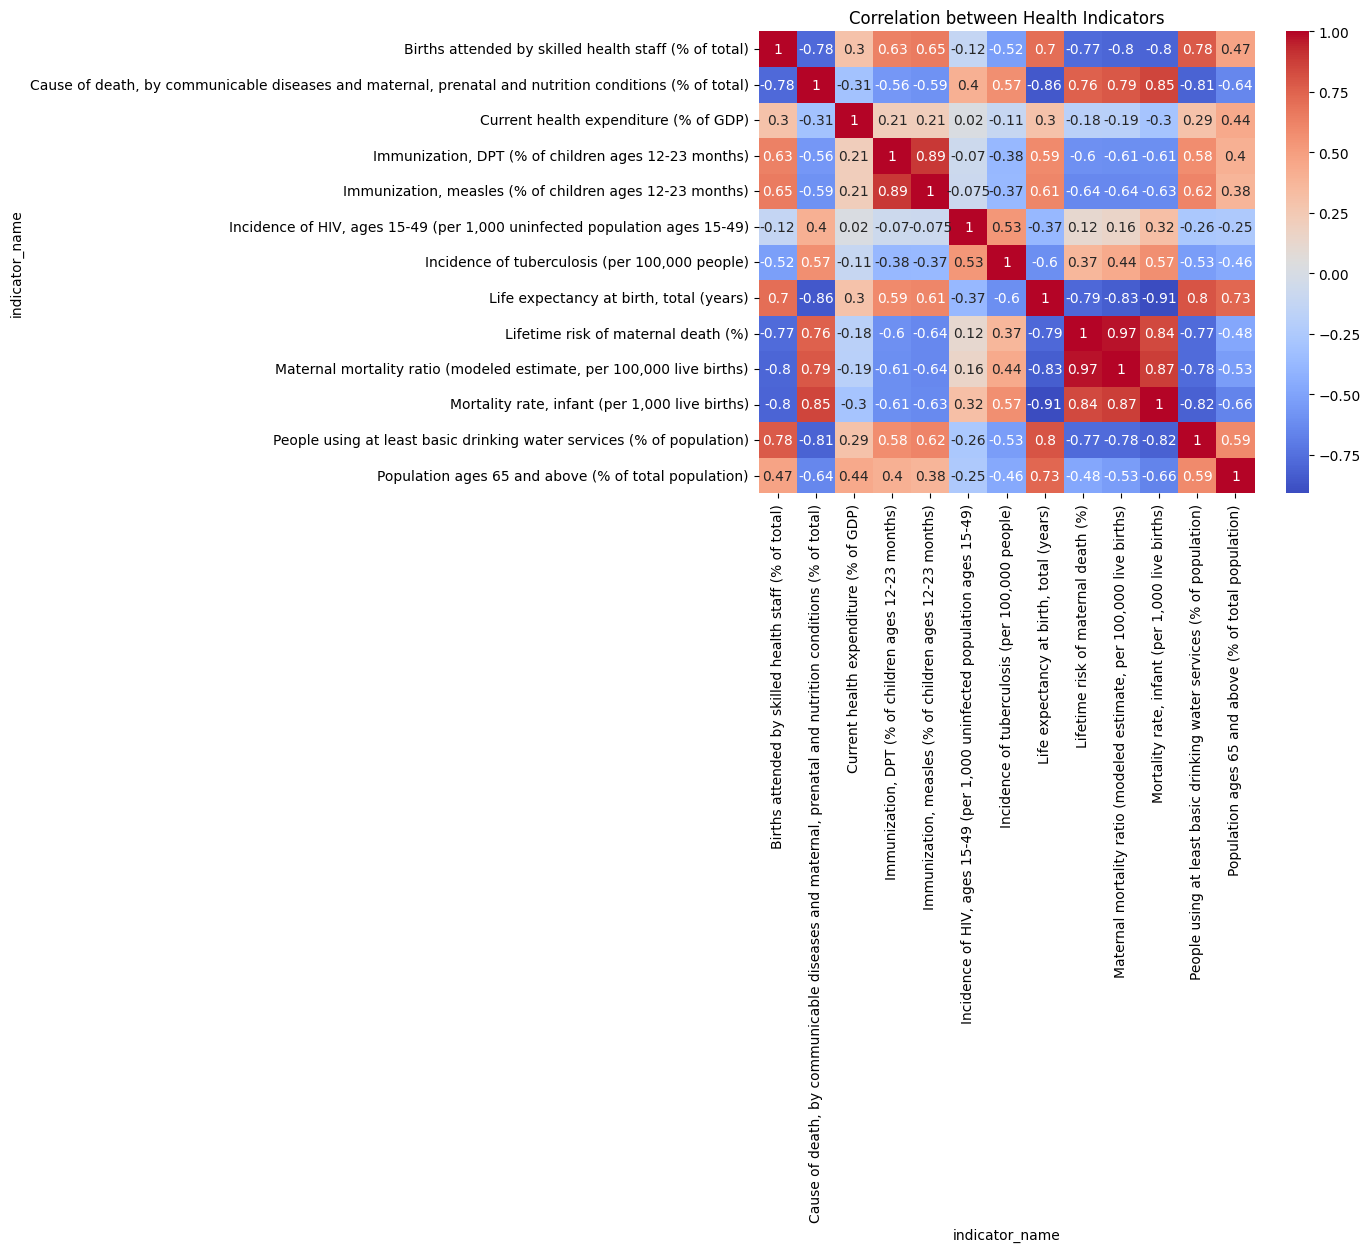

In [58]:

df_wide = health.pivot_table(
    index=["country_value", "year"],
    columns="indicator_name",
    values="value"
)

corr = df_wide.corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    annot_kws={"fontsize": 10}
)
plt.title("Correlation between Health Indicators")
plt.show()

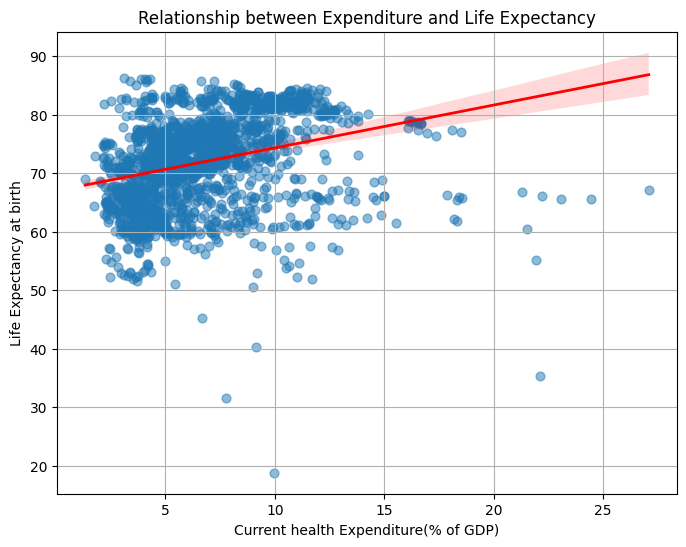

In [59]:
df_pivot= health.pivot(index=["country_value", "year"], columns="indicator_name", values="value").reset_index()

plt.figure(figsize=(8,6), facecolor="none")

ax=sns.regplot(data=df_pivot,
               x="Current health expenditure (% of GDP)",
               y="Life expectancy at birth, total (years)",
               scatter_kws= {"alpha":0.5, "s":40},
               line_kws={"color":"red","lw":2}
               )

plt.title("Relationship between Expenditure and Life Expectancy")
plt.xlabel("Current health Expenditure(% of GDP)")
plt.ylabel("Life Expectancy at birth")
plt.grid(True)
plt.show()

"Note: Due to API rate limiting, data is loaded from pre-fetched CSV files. The API fetching code above demonstrates the full data collection pipeline."